# Exploratory Data Analysis (EDA)

This notebook summarizes key transaction, promotion, and margin patterns for the project.
Outputs are saved to `reports/figures` using the `eda_*` naming scheme.

In [18]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path("..").resolve()
DATA_DIR = REPO_ROOT / "data" / "02_processed"
FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

COLORS = {
    "primary": "#4F8FF0",
    "accent": "#F08F50",
    "success": "#50F08F",
    "muted": "#9CA3AF",
    "ink": "#1F2937"
}

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight")
    return path

def format_axes(ax):
    ax.grid(True, axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    return ax

In [19]:
tx = pd.read_parquet(DATA_DIR / "master_transactions.parquet")
margin = pd.read_csv(DATA_DIR / "commodity_margin.csv")

required_cols = {"household_key", "BASKET_ID", "COMMODITY_DESC", "Is_Promoted_Item", "Revenue_Retailer"}
missing = sorted(required_cols - set(tx.columns))
if missing:
    raise ValueError(f"Missing required columns in master_transactions: {missing}")

print("Transactions shape:", tx.shape)
print("Margin shape:", margin.shape)
print("Columns sample:", sorted(tx.columns)[:12])

Transactions shape: (2216946, 31)
Margin shape: (308, 3)
Columns sample: ['BASKET_ID', 'BRAND', 'Basket_Is_Organic', 'COMMODITY_DESC', 'Coupon_Discount_Total', 'Coupon_Match_Discount_Total', 'DAY', 'DEPARTMENT', 'Distinct_SKU_Count', 'Distinct_Subcommodity_Count', 'HOMEOWNER_DESC', 'Is_Promoted_Item']


## Transaction volume and basket statistics

In [20]:
basket_commodities = tx.groupby("BASKET_ID")["COMMODITY_DESC"].nunique()
baskets_per_user = tx.groupby("household_key")["BASKET_ID"].nunique()

summary = pd.DataFrame(
    {
        "unique_baskets": [tx["BASKET_ID"].nunique()],
        "unique_households": [tx["household_key"].nunique()],
        "avg_baskets_per_user": [baskets_per_user.mean()],
        "avg_distinct_commodities_per_basket": [basket_commodities.mean()],
    }
)
summary.round(2)

,unique_baskets,unique_households,avg_baskets_per_user,avg_distinct_commodities_per_basket
0,275889,2500,110.36,6.9


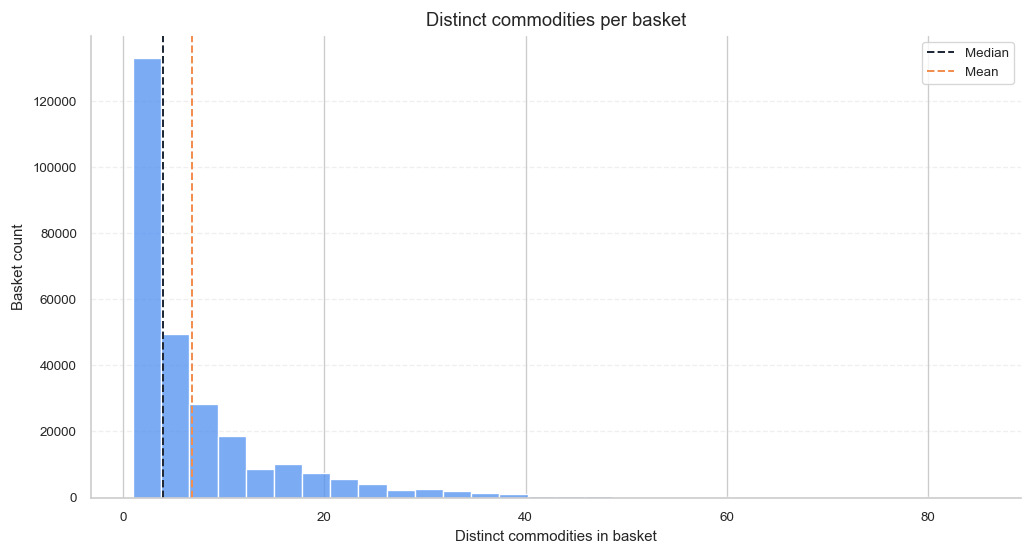

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(basket_commodities, bins=30, color=COLORS["primary"], ax=ax)
ax.axvline(basket_commodities.median(), color=COLORS["ink"], linestyle="--", label="Median")
ax.axvline(basket_commodities.mean(), color=COLORS["accent"], linestyle="--", label="Mean")
ax.set_title("Distinct commodities per basket")
ax.set_xlabel("Distinct commodities in basket")
ax.set_ylabel("Basket count")
format_axes(ax)
ax.legend()
save_fig(fig, "eda_basket_diversity.png")
plt.show()

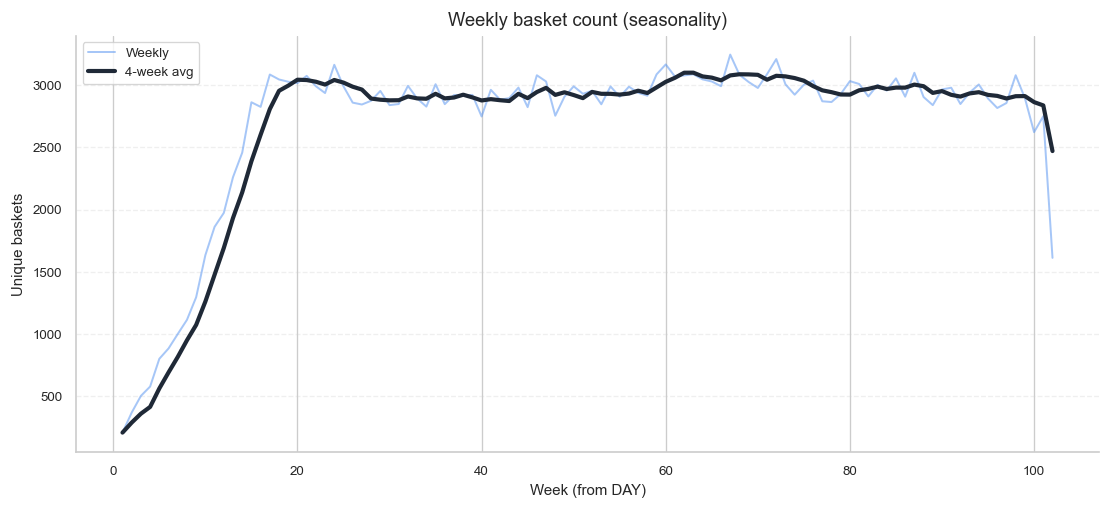

In [22]:
if "DAY" in tx.columns:
    week_index = ((tx["DAY"] - tx["DAY"].min()) // 7).astype(int) + 1
    time_label = "Week (from DAY)"
elif "WEEK_NO" in tx.columns:
    week_index = tx["WEEK_NO"].astype(int)
    time_label = "Week number"
else:
    week_index = None

if week_index is None:
    print("No DAY or WEEK_NO column found; skipping weekly basket count plot.")
else:
    basket_by_week = (
        tx.assign(week=week_index)
        .groupby("week")["BASKET_ID"]
        .nunique()
        .sort_index()
    )
    rolling = basket_by_week.rolling(4, min_periods=1).mean()
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(basket_by_week.index, basket_by_week.values, color=COLORS["primary"], alpha=0.5, label="Weekly")
    ax.plot(rolling.index, rolling.values, color=COLORS["ink"], linewidth=2.5, label="4-week avg")
    ax.set_title("Weekly basket count (seasonality)")
    ax.set_xlabel(time_label)
    ax.set_ylabel("Unique baskets")
    format_axes(ax)
    ax.legend()
    save_fig(fig, "eda_weekly_baskets.png")
    plt.show()

## Promotion analysis

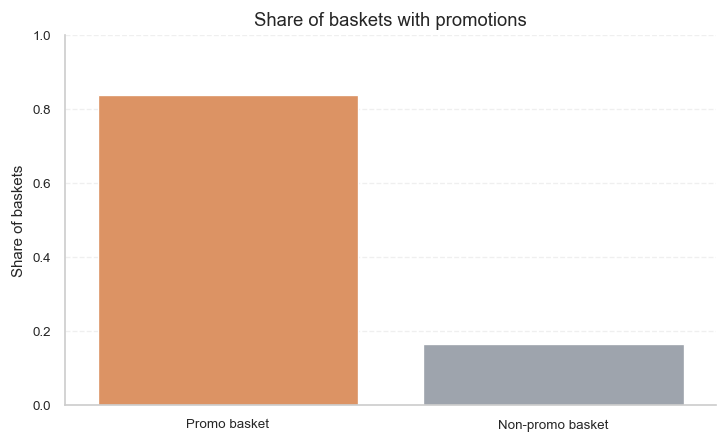

Share of baskets with at least one promoted item: 83.68%


In [23]:
basket_has_promo = tx.groupby("BASKET_ID")["Is_Promoted_Item"].any()
promo_share = basket_has_promo.mean()
promo_frame = pd.DataFrame(
    {
        "basket_type": ["Promo basket", "Non-promo basket"],
        "share": [promo_share, 1 - promo_share]
    }
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=promo_frame,
    x="basket_type",
    y="share",
    hue="basket_type",
    palette=[COLORS["accent"], COLORS["muted"]],
    legend=False,
    ax=ax,
)
ax.set_title("Share of baskets with promotions")
ax.set_ylabel("Share of baskets")
ax.set_xlabel("")
ax.set_ylim(0, 1)
format_axes(ax)
save_fig(fig, "eda_promo_penetration.png")
plt.show()

print(f"Share of baskets with at least one promoted item: {promo_share:.2%}")

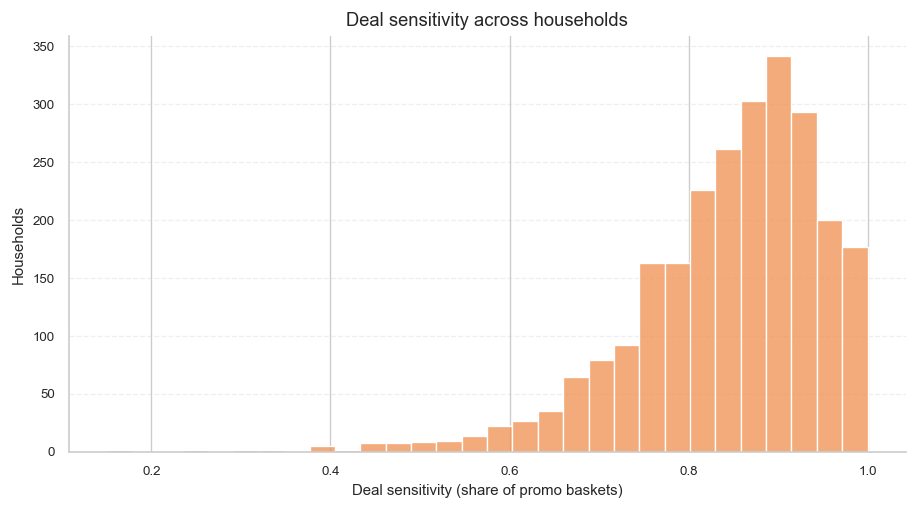

In [24]:
from src.utility_scorer import calculate_deal_sensitivity

deal_sensitivity = calculate_deal_sensitivity(tx)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(deal_sensitivity["deal_sensitivity"], bins=30, color=COLORS["accent"], ax=ax)
ax.set_title("Deal sensitivity across households")
ax.set_xlabel("Deal sensitivity (share of promo baskets)")
ax.set_ylabel("Households")
format_axes(ax)
save_fig(fig, "eda_deal_sensitivity.png")
plt.show()

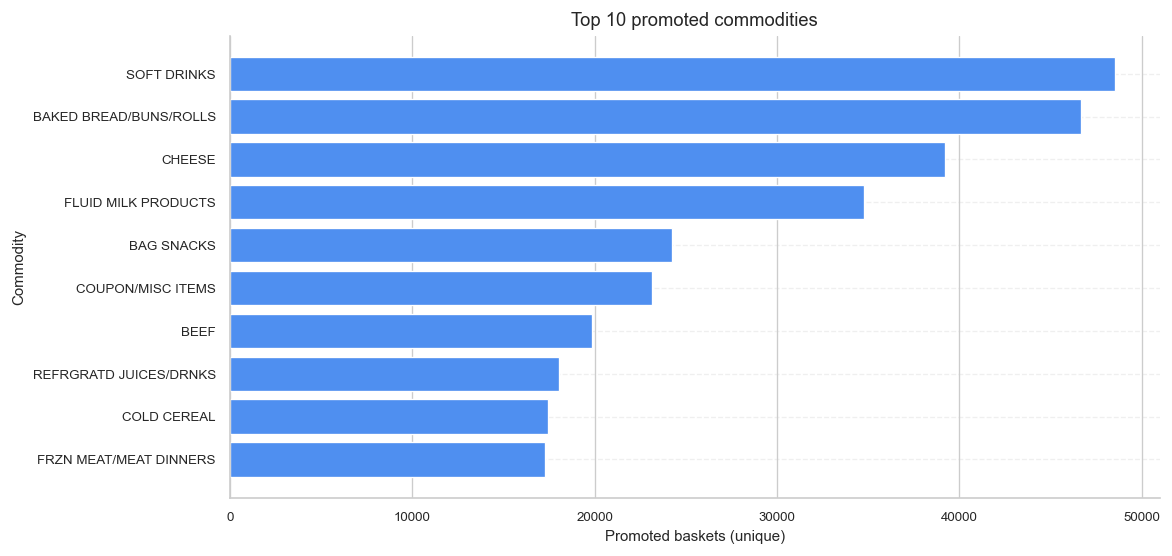

In [25]:
promoted = tx.loc[tx["Is_Promoted_Item"]].copy()
top_promoted = (
    promoted.groupby("COMMODITY_DESC", observed=False)["BASKET_ID"]
    .nunique()
    .nlargest(10)
    .sort_values()
    .reset_index(name="promo_baskets")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_promoted["COMMODITY_DESC"], top_promoted["promo_baskets"], color=COLORS["primary"])
ax.set_title("Top 10 promoted commodities")
ax.set_xlabel("Promoted baskets (unique)")
ax.set_ylabel("Commodity")
format_axes(ax)
save_fig(fig, "eda_top_promoted.png")
plt.show()

## Margin analysis

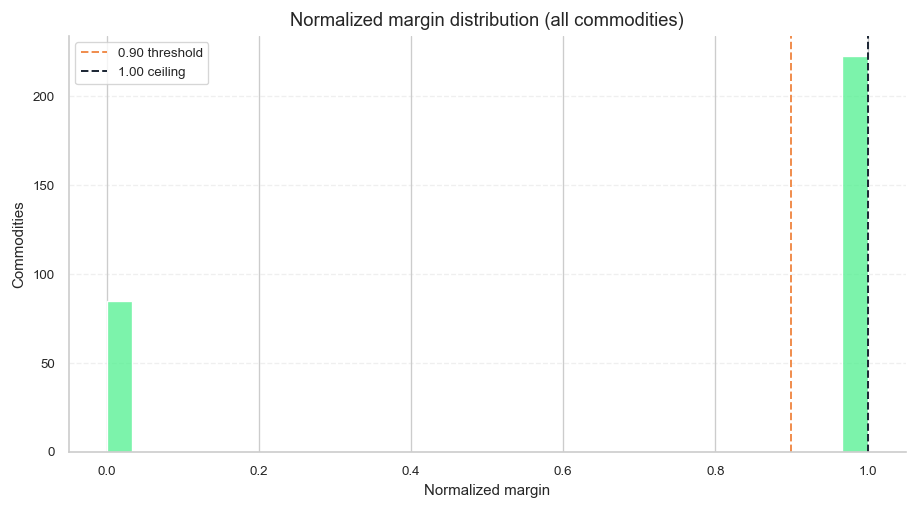

Share of commodities with margin >= 0.90: 72.40%
Share of commodities with margin near 1.0: 72.40%


In [26]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(margin["Normalized_Margin"], bins=30, color=COLORS["success"], ax=ax)
ax.axvline(0.9, color=COLORS["accent"], linestyle="--", label="0.90 threshold")
ax.axvline(1.0, color=COLORS["ink"], linestyle="--", label="1.00 ceiling")
ax.set_title("Normalized margin distribution (all commodities)")
ax.set_xlabel("Normalized margin")
ax.set_ylabel("Commodities")
format_axes(ax)
ax.legend()
save_fig(fig, "eda_margin_distribution.png")
plt.show()

share_high = (margin["Normalized_Margin"] >= 0.9).mean()
share_at_one = (margin["Normalized_Margin"] >= 0.999).mean()
print(f"Share of commodities with margin >= 0.90: {share_high:.2%}")
print(f"Share of commodities with margin near 1.0: {share_at_one:.2%}")

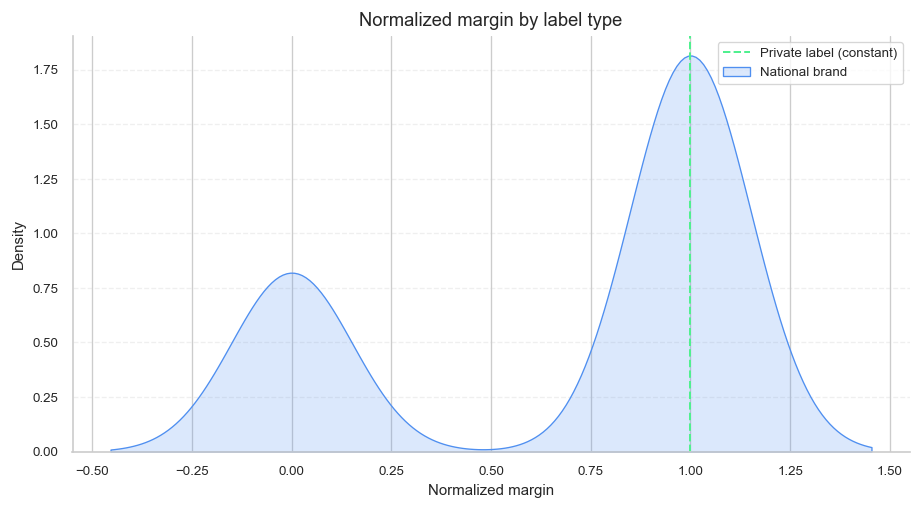

In [27]:
if "BRAND" not in tx.columns:
    print("No BRAND column found; skipping label-level margin plot.")
else:
    brand_text = tx["BRAND"].astype("string").fillna("").str.upper()
    label_type = np.select(
        [
            brand_text.str.contains("PRIVATE", na=False),
            brand_text.str.contains("NATIONAL", na=False),
        ],
        ["Private label", "National brand"],
        default="Other",
    )
    label_by_commodity = (
        tx.assign(label_type=label_type)
        .groupby("COMMODITY_DESC", observed=False)["label_type"]
        .agg(lambda series: series.value_counts().idxmax())
        .rename("label_type")
    )
    margin_labeled = margin.merge(label_by_commodity, on="COMMODITY_DESC", how="left")

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for label, color in zip(
        ["Private label", "National brand", "Other"],
        [COLORS["success"], COLORS["primary"], COLORS["muted"]],
    ):
        subset = margin_labeled.loc[margin_labeled["label_type"] == label, "Normalized_Margin"].dropna()
        if subset.empty:
            continue
        if subset.nunique() <= 1:
            ax.axvline(subset.iloc[0], color=color, linestyle="--", label=f"{label} (constant)")
        else:
            sns.kdeplot(
                subset,
                label=label,
                fill=True,
                alpha=0.2,
                ax=ax,
                color=color,
                warn_singular=False,
            )
    ax.set_title("Normalized margin by label type")
    ax.set_xlabel("Normalized margin")
    ax.set_ylabel("Density")
    format_axes(ax)
    ax.legend()
    save_fig(fig, "eda_margin_by_label.png")
    plt.show()

## Household segmentation preview (k-means)

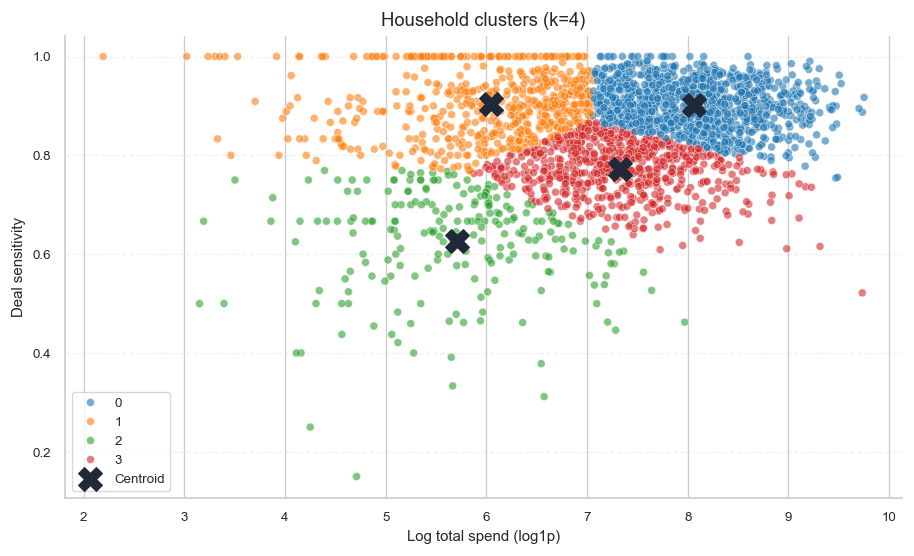

In [28]:
import warnings

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

household_spend = tx.groupby("household_key")["Revenue_Retailer"].sum().rename("total_spend")
deal_sensitivity_lookup = deal_sensitivity.set_index("household_key")

features = household_spend.to_frame().join(deal_sensitivity_lookup, how="left")
features["deal_sensitivity"] = features["deal_sensitivity"].fillna(0.0)
features["log_spend"] = np.log1p(features["total_spend"])
features = features.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_spend", "deal_sensitivity"])

X = features[["log_spend", "deal_sensitivity"]].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn")
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    features["cluster"] = kmeans.fit_predict(X_scaled)

centroids = features.groupby("cluster")[["log_spend", "deal_sensitivity"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=features.reset_index(),
    x="log_spend",
    y="deal_sensitivity",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    ax=ax,
)
ax.scatter(centroids["log_spend"], centroids["deal_sensitivity"], s=200, c=COLORS["ink"], marker="X", label="Centroid")
ax.set_title("Household clusters (k=4)")
ax.set_xlabel("Log total spend (log1p)")
ax.set_ylabel("Deal sensitivity")
format_axes(ax)
ax.legend()
save_fig(fig, "eda_kmeans_clusters.png")
plt.show()

## Key findings from the dataset include:

- Basket diversity is modest, with distinct commodities per basket clustering in the low single digits. This confirms a large cross-sell surface area where personalization can expand baskets beyond a few staple categories.
- Weekly basket volume shows clear time variation, indicating seasonality and shopping cadence effects. This supports using time-aware validation when comparing campaign impact across periods.
- Promotions appear in a meaningful share of baskets, showing that discounting is a common shopping context. This justifies separating promotional effects from baseline affinity signals in modeling.
- Deal sensitivity varies widely across households, with both low- and high-sensitivity tails. This heterogeneity motivates targeting strategies that adapt promotion intensity by segment.
- Promotion activity is concentrated in a small set of commodity groups, suggesting a limited set of categories drive most deal behavior. These categories are strong candidates for testing incremental uplift.
- Normalized margins are skewed high, with a sizable fraction of commodities near 1.0, reflecting the proxy-based margin assignment. This should be called out as a conservative assumption when interpreting margin lift.
- Private label items exhibit higher normalized margins than national brands, reinforcing the mix-shift opportunity in recommendations. This aligns with margin-aware ranking objectives.
- The k-means preview reveals distinct spend and deal-sensitivity clusters, consistent with heterogeneous treatment effects. Per Kohavi et al.'s guidance for A/B tests, these segments provide a basis for stratified evaluation.